# Метод 3 — Monte Carlo. Часть 1: наивный NB-сэмплер и его сходимость

- Для каждого пользователя считаем индивидуальную интенсивность `rate_i = n_imps_before / cutoff_hour`.
- Для кампании длительностью `duration` параметр среднего: `mu_ij = rate_i * duration`.
- Сэмплируем `S` реализаций `X_ij ~ NB(mu_ij, alpha)` и оцениваем reach@k = доля пользователей с `X >= k`

In [4]:
from __future__ import annotations

import sys
from pathlib import Path
from dataclasses import dataclass

ROOT = Path('/Users/ensamsanovich/auc_forecast')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT_DIR = ROOT / 'outputs' / 'method_3_monte_carlo'
OUT_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from core.config import ALPHA, MC_N_SIMS, SEED, TARGETS, set_seed
from core.runner import load_unified_data
from core.metrics import smlar

set_seed()

In [5]:
data = load_unified_data()
val = data['val']
ans = data['ans']
user_index = data['user_index']
split = data['split']
y = ans[list(TARGETS)].astype(float).values

print(f"val: {val.shape}")
print(f"ans: {ans.shape}")
print(f"train/holdout: {len(split['train_idx'])}/{len(split['holdout_idx'])}")
print(f"folds: {len(split['folds'])}")

val: (1008, 6)
ans: (1008, 3)
train/holdout: 806/202
folds: 5


### NB-сэмплер и MCResult
`MCResult` хранит матрицу `(S, n_targets)` и считает среднее, std, квантили и доверительные интервалы.

In [7]:
def _nb_sample(mu, alpha, size, rng):
    mu = np.asarray(mu, dtype=np.float64)
    alpha = np.asarray(alpha, dtype=np.float64)
    out = np.empty(size, dtype=np.int64)
    poisson_mask = alpha < 1e-6
    if poisson_mask.any():
        out = rng.poisson(np.broadcast_to(mu, size).copy(), size=size)
    if (~poisson_mask).any():
        n = 1.0 / np.where(poisson_mask, 1.0, alpha)
        p = n / (n + mu)
        n = np.broadcast_to(n, size).copy()
        p = np.broadcast_to(p, size).copy()
        out_nb = rng.negative_binomial(n, p, size=size)
        out = np.where(np.broadcast_to(poisson_mask, size), out, out_nb)
    return out

@dataclass
class MCResult:
    reach_samples: np.ndarray
    thresholds: tuple
    @property
    def mean(self):
        return self.reach_samples.mean(axis=0)
    @property
    def std(self):
        return self.reach_samples.std(axis=0)
    def quantile(self, q):
        return np.quantile(self.reach_samples, q, axis=0)
    def credible_interval(self, alpha=0.10):
        return self.quantile(alpha / 2), self.quantile(1 - alpha / 2)

def simulate_reach(mu, alpha, n_simulations=500, thresholds=(1, 2, 3), seed=42):
    mu = np.asarray(mu, dtype=np.float64).ravel()
    if np.isscalar(alpha):
        alpha = np.full_like(mu, float(alpha))
    else:
        alpha = np.asarray(alpha, dtype=np.float64).ravel()
    n_users = mu.shape[0]
    if n_users == 0:
        return MCResult(np.zeros((n_simulations, len(thresholds))), thresholds)
    rng = np.random.default_rng(seed)
    samples = _nb_sample(mu, alpha, size=(n_simulations, n_users), rng=rng)
    reach = np.stack([(samples >= k).mean(axis=1) for k in thresholds], axis=1)
    return MCResult(reach_samples=reach, thresholds=tuple(thresholds))

### Per-user rates и наивная MC по кампании

Они вычисляют интенсивности и среднее по `MCResult` для одной кампании, а затем по всему `val_df`.

In [8]:
def _per_user_rates(user_ids, cutoff_hour, user_index):
    rates = []
    for uid in user_ids:
        feats = user_index.user_features_before(int(uid), cutoff_hour)
        n_imps = feats[0]
        is_cold = feats[4]
        if is_cold == 1.0 or cutoff_hour == 0:
            rates.append(np.nan)
        else:
            rates.append(n_imps / max(cutoff_hour, 1))
    rates = np.array(rates, dtype=np.float64)
    known = rates[~np.isnan(rates)]
    fallback = float(np.mean(known)) if known.size else 0.0
    rates = np.where(np.isnan(rates), fallback, rates)
    return rates

def _naive_mc_per_campaign(val_row, user_index, alpha, n_sims, seed):
    cutoff = int(val_row['hour_start'])
    duration = int(val_row['hour_end'] - val_row['hour_start'])
    user_ids = val_row['user_ids']
    rates = _per_user_rates(user_ids, cutoff, user_index)
    mu = rates * max(duration, 1)
    mu = np.clip(mu, 1e-6, 1e3)
    res = simulate_reach(mu, alpha=alpha, n_simulations=n_sims, seed=seed)
    lo, hi = res.credible_interval(alpha=ALPHA)
    return res.mean, lo, hi, res

def _build_naive_predictions(val_df, user_index, alpha_disp, n_sims):
    means = np.zeros((len(val_df), 3))
    lows = np.zeros((len(val_df), 3))
    highs = np.zeros((len(val_df), 3))
    for i in range(len(val_df)):
        m, lo, hi, _ = _naive_mc_per_campaign(
            val_df.iloc[i], user_index, alpha_disp, n_sims, seed=SEED + i,
        )
        means[i], lows[i], highs[i] = m, lo, hi
    return means, lows, highs

### Распределение reach для одной кампании при разных S

Берём первую кампанию из `val` и для S in [10, 50, 100, 500, 1000, 5000] изучаем,
как меняется форма распределения reach@1 (histograms).

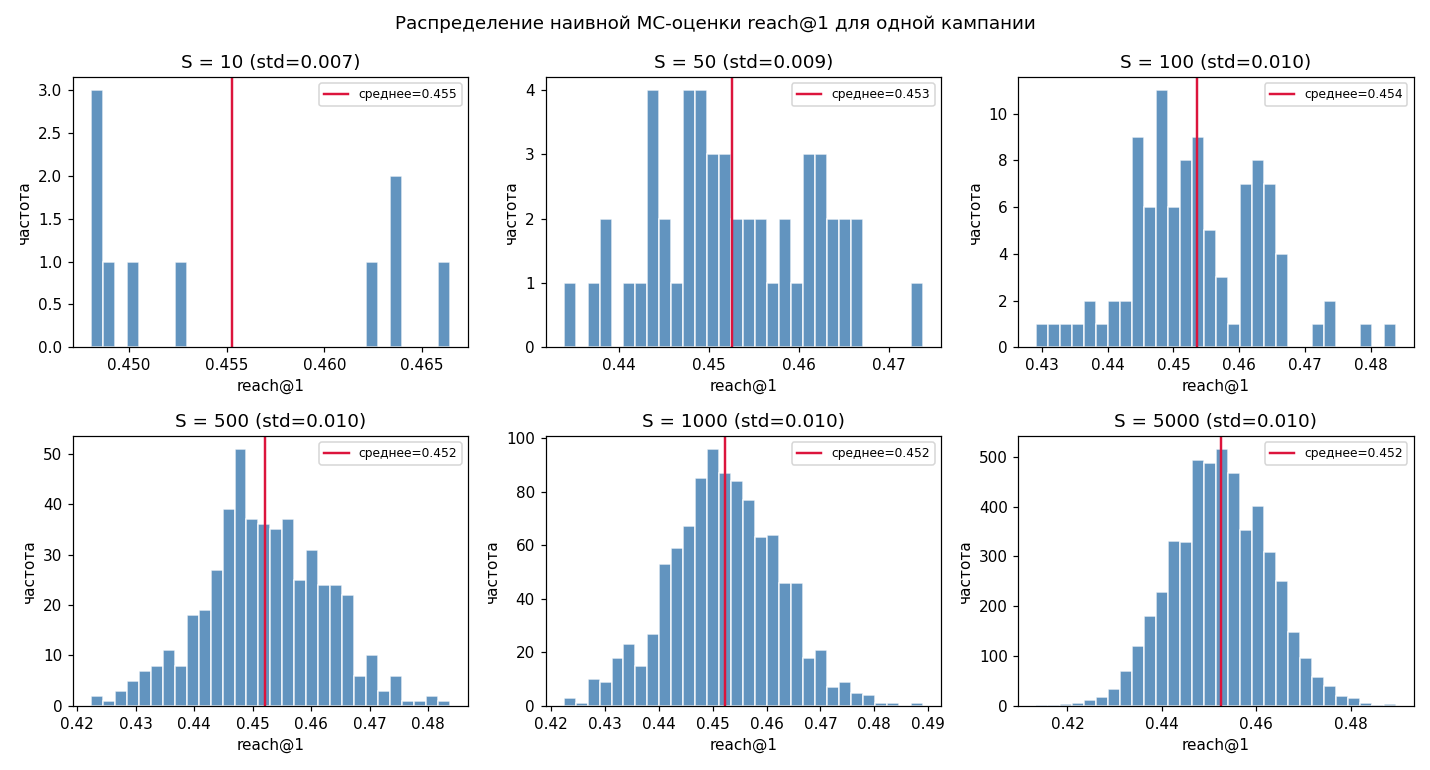

In [9]:
ALPHA_DISP = 2.21
row = val.iloc[0]
cutoff = int(row['hour_start'])
duration = int(row['hour_end'] - row['hour_start'])
rates_one = _per_user_rates(row['user_ids'], cutoff, user_index)
mu_one = np.clip(rates_one * max(duration, 1), 1e-6, 1e3)

S_grid_hist = [10, 50, 100, 500, 1000, 5000]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, S in zip(axes.flat, S_grid_hist):
    res = simulate_reach(mu_one, alpha=ALPHA_DISP, n_simulations=S, seed=SEED)
    samp1 = res.reach_samples[:, 0]
    ax.hist(samp1, bins=30, color='steelblue', alpha=0.85, edgecolor='white')
    ax.axvline(samp1.mean(), color='crimson', lw=1.6, label=f"среднее={samp1.mean():.3f}")
    ax.set_title(f"S = {S} (std={samp1.std():.3f})")
    ax.set_xlabel('reach@1')
    ax.set_ylabel('частота')
    ax.legend(loc='upper right', fontsize=8)
plt.suptitle('Распределение наивной MC-оценки reach@1 для одной кампании')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_reach_distribution_by_S.png', dpi=110)
plt.close()
display(Image(filename=str(OUT_DIR / 'fig_reach_distribution_by_S.png')))

Чтобы выбрать рабочее значение `S`, прогоняем наивный MC на подвыборке кампаний для разных S
и смотрим, при каком S оценка SMLAR стабилизируется.

In [11]:
rng = np.random.default_rng(SEED)
subset_idx = rng.choice(len(val), size=min(80, len(val)), replace=False)
subset_idx = np.sort(subset_idx)
val_sub = val.iloc[subset_idx].reset_index(drop=True)
y_sub = y[subset_idx]

S_GRID = [10, 25, 50, 100, 250, 500, 1000, 2500, 5000]
smlar_by_S = []
for S in S_GRID:
    means_S, _, _ = _build_naive_predictions(val_sub, user_index, ALPHA_DISP, S)
    means_S = np.clip(means_S, 0.0, 1.0)
    smlar_by_S.append(float(smlar(y_sub, means_S)))
    print(f"  S={S:5d}: SMLAR={smlar_by_S[-1]:.2f}%")

  S=   10: SMLAR=354.73%
  S=   25: SMLAR=354.09%
  S=   50: SMLAR=354.99%
  S=  100: SMLAR=354.84%
  S=  250: SMLAR=354.69%
  S=  500: SMLAR=354.59%
  S= 1000: SMLAR=354.34%
  S= 2500: SMLAR=354.32%
  S= 5000: SMLAR=354.31%


  saved fig_convergence_step_001.png
  saved fig_convergence_step_002.png
  saved fig_convergence_step_003.png
  saved fig_convergence_step_004.png
  saved fig_convergence_step_005.png
  saved fig_convergence_step_006.png
  saved fig_convergence_step_007.png
  saved fig_convergence_step_008.png
  saved fig_convergence_step_009.png


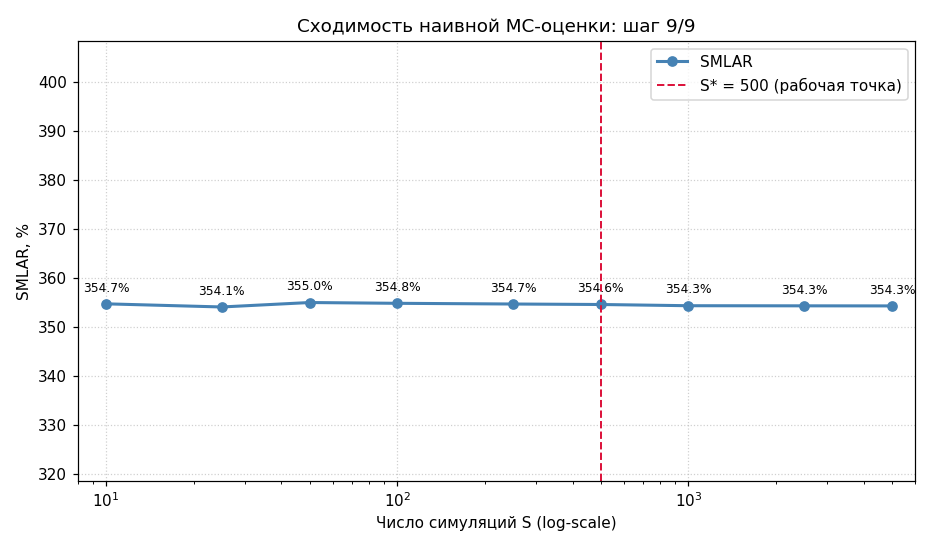

In [12]:
S_arr = np.array(S_GRID)
sm_arr = np.array(smlar_by_S)
y_max = float(np.max(sm_arr)) * 1.15
y_min = float(np.min(sm_arr)) * 0.9

for step in range(1, len(S_GRID) + 1):
    fig, ax = plt.subplots(figsize=(8.5, 5.0))
    ax.plot(S_arr[:step], sm_arr[:step], marker='o', color='steelblue', lw=2, label='SMLAR')
    for i in range(step):
        ax.annotate(f"{sm_arr[i]:.1f}%", (S_arr[i], sm_arr[i]),
                    textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
    if step == len(S_GRID):
        ax.axvline(500, color='crimson', ls='--', lw=1.3, label='S* = 500 (рабочая точка)')
    ax.set_xscale('log')
    ax.set_xlim(8, 6000)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('Число симуляций S (log-scale)')
    ax.set_ylabel('SMLAR, %')
    ax.set_title(f"Сходимость наивной MC-оценки: шаг {step}/{len(S_GRID)}")
    ax.grid(True, ls=':', alpha=0.6)
    ax.legend(loc='upper right')
    out_path = OUT_DIR / f"fig_convergence_step_{step:03d}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=110)
    plt.close()
    print(f"  saved {out_path.name}")

display(Image(filename=str(OUT_DIR / f"fig_convergence_step_{len(S_GRID):03d}.png")))